# Iris Data Generation

# Index

1. [Libraries](#Libraries)
2. [Classifying Real Data](#Real-Data-Classification)
3. [Generating Syntethic Data](#Conditional-Generative-Adversarial-Network)
4. [Syntethic VS Real](#Quality-assessment)
5. [Conclusion](#Conclusion)

## Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.functional as F
from torch.utils.data import Dataset, DataLoader

import torchmetrics

from tqdm.auto import tqdm

In [2]:
data = load_iris()
data_dim = data['data'].shape[1]
target_dim = len(np.unique(data['target']))

load_pretrained_real_clf = False
models_path = 'Models/'
real_data_clf_name = 'real_clf.pth'

bs = 32
clf_lr = 1e-3
clf_epochs = 500
eval_step = 50

## Real Data Classification

In [3]:
X_real, y_real = data['data'], data['target']

X_real_train, X_real_val, y_real_train, y_real_val = train_test_split(X_real, y_real, test_size = 0.2, 
                                                                      stratify = y_real, random_state = 0)

std_scl = StandardScaler()
X_real_train = std_scl.fit_transform(X_real_train)
X_real_val = std_scl.transform(X_real_val)

print(f'{X_real_train.shape[0]} train instances\n{X_real_val.shape[0]} validation instances')

120 train instances
30 validation instances


In [4]:
class IrisDataset(Dataset):
    def __init__(self, data, target):
        self.data = torch.tensor(data, dtype = torch.float32)
        self.label = torch.tensor(target, dtype = torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.label[idx]

real_dataset_train = IrisDataset(X_real_train, y_real_train)
real_dataset_val = IrisDataset(X_real_val, y_real_val)

real_dataloader_train = DataLoader(real_dataset_train, batch_size = bs, shuffle = True)

for i in real_dataloader_train:
    real_batch = i
    break
real_batch

[tensor([[-0.7722, -0.7844,  0.0791,  0.2521],
         [-0.3024, -1.2336,  0.0791, -0.1408],
         [ 0.7546, -0.1104,  0.9776,  0.7759],
         [-1.0071,  0.3388, -1.4371, -1.3193],
         [ 0.9895,  0.5635,  1.0899,  1.6925],
         [-1.7118,  0.3388, -1.3809, -1.3193],
         [ 1.4593, -0.1104,  1.2022,  1.1687],
         [ 1.2244,  0.1142,  0.7529,  1.4306],
         [ 1.8116, -0.5597,  1.3145,  0.9068],
         [ 1.5767,  0.3388,  1.2583,  0.7759],
         [ 0.2848, -0.1104,  0.4722,  0.2521],
         [-1.0071,  0.7881, -1.2686, -1.3193],
         [-0.7722,  2.3606, -1.2686, -1.4502],
         [ 0.4023, -0.3351,  0.3037,  0.1211],
         [-0.1850,  1.6867, -1.1563, -1.1883],
         [ 2.0465, -0.1104,  1.5953,  1.1687],
         [ 0.5197, -1.2336,  0.6406,  0.3830],
         [ 0.7546,  0.3388,  0.7529,  1.0378],
         [ 1.2244,  0.3388,  1.0899,  1.4306],
         [ 2.1640, -0.1104,  1.3145,  1.4306],
         [ 0.5197, -1.6829,  0.3599,  0.1211],
         [-0.

In [5]:
class Classifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        
        self.Classifier = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, output_dim)
        )
        
    def forward(self, x):
        x = self.Classifier(x)
        return x
    
real_clf = Classifier(input_dim = data_dim, output_dim = target_dim)
real_clf(real_batch[0])

tensor([[-0.0577, -0.0590, -0.1809],
        [-0.0620, -0.0435, -0.1845],
        [-0.0455, -0.0680, -0.1899],
        [-0.0461, -0.0381, -0.1952],
        [-0.0359, -0.0887, -0.1877],
        [-0.0364, -0.0388, -0.1989],
        [-0.0527, -0.0759, -0.1765],
        [-0.0396, -0.0871, -0.1804],
        [-0.0636, -0.0628, -0.1754],
        [-0.0606, -0.0784, -0.1722],
        [-0.0577, -0.0601, -0.1836],
        [-0.0410, -0.0438, -0.1930],
        [-0.0474, -0.0495, -0.1858],
        [-0.0617, -0.0554, -0.1804],
        [-0.0683, -0.0473, -0.1783],
        [-0.0614, -0.0737, -0.1713],
        [-0.0641, -0.0434, -0.1832],
        [-0.0430, -0.0820, -0.1867],
        [-0.0414, -0.0850, -0.1829],
        [-0.0604, -0.0785, -0.1695],
        [-0.0680, -0.0457, -0.1797],
        [-0.0485, -0.0434, -0.1900],
        [-0.0651, -0.0552, -0.1795],
        [-0.0624, -0.0580, -0.1782],
        [-0.0643, -0.0589, -0.1776],
        [-0.0575, -0.0594, -0.1852],
        [-0.0437, -0.0656, -0.1937],
 

In [6]:
real_clf_opt = torch.optim.AdamW(real_clf.parameters(), lr = clf_lr)
clf_criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')

In [7]:
if load_pretrained_real_clf:
    
    prev_model_save_info = torch.load(models_path + real_data_clf_name)
    
    real_clf.load_state_dict(prev_model_save_info["model_state_dict"])
    best_val_loss = prev_model_save_info["best_val_loss"]
    
    print(f'Loading pretrained Real Data Classifier with loss {best_val_loss:.4f}')
    
else:
    for epoch in tqdm(range(clf_epochs), desc = 'Training Classifier'):
    
        epoch_train_loss = 0
        
        for batch, (data, label) in enumerate(real_dataloader_train):
            
            real_clf.train()
            real_clf.zero_grad()
            
            y_pred_logits = real_clf(data)
            loss = clf_criterion(y_pred_logits, label)
            epoch_train_loss += loss.item()
            
            loss.backward()
            real_clf_opt.step()
            
        with torch.no_grad():
            real_clf.eval()
            y_pred_val = real_clf(real_dataset_val.data)
            epoch_val_loss = clf_criterion(y_pred_val, real_dataset_val.label).item()
            
            
        epoch_train_loss = epoch_train_loss/len(real_dataloader_train)
            
        if epoch % eval_step == 0 or epoch == clf_epochs:
            print(f'Epoch {epoch}/{clf_epochs} Train {epoch_train_loss:.4f} | Val Loss {epoch_val_loss:.4f}')
            
            if epoch_val_loss < best_val_loss:
                
                best_val_loss = epoch_val_loss
                
                real_clf_save_info = {
                    "model_state_dict": real_clf.state_dict(),
                    "best_val_loss": epoch_val_loss
                }
                
                torch.save(real_clf_save_info, models_path+real_data_clf_name)
                print(f"[CHECKPOINT] Saved with loss {epoch_val_loss:.4f}\n")

Training Classifier:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 0/500 Train 1.0910 | Val Loss 1.0852
[CHECKPOINT] Saved with loss 1.0852

Epoch 50/500 Train 0.4389 | Val Loss 0.5035
[CHECKPOINT] Saved with loss 0.5035

Epoch 100/500 Train 0.0614 | Val Loss 0.0580
[CHECKPOINT] Saved with loss 0.0580

Epoch 150/500 Train 0.0424 | Val Loss 0.0409
[CHECKPOINT] Saved with loss 0.0409

Epoch 200/500 Train 0.0394 | Val Loss 0.0377
[CHECKPOINT] Saved with loss 0.0377

Epoch 250/500 Train 0.0333 | Val Loss 0.0342
[CHECKPOINT] Saved with loss 0.0342

Epoch 300/500 Train 0.0345 | Val Loss 0.0374
Epoch 350/500 Train 0.0313 | Val Loss 0.0302
[CHECKPOINT] Saved with loss 0.0302

Epoch 400/500 Train 0.0233 | Val Loss 0.0291
[CHECKPOINT] Saved with loss 0.0291

Epoch 450/500 Train 0.0193 | Val Loss 0.0322


In [8]:
acc = torchmetrics.Accuracy(task = "multiclass", num_classes = target_dim)
prec = torchmetrics.Precision(task = "multiclass", num_classes = target_dim)
rec = torchmetrics.Recall(task = "multiclass", num_classes = target_dim)
f1 = torchmetrics.F1Score(task = "multiclass", num_classes = target_dim)

accuracy = acc(real_clf(real_dataset_val.data), real_dataset_val.label)
precision = prec(real_clf(real_dataset_val.data), real_dataset_val.label)
recall = rec(real_clf(real_dataset_val.data), real_dataset_val.label)
F1 = f1(real_clf(real_dataset_val.data), real_dataset_val.label)

print(f'Accuracy {accuracy:.4%}\nPrecision {precision:.4%}\nRecall {recall:.4%}\nF1 {F1:.4%}')

if epoch_val_loss < best_val_loss:

        real_clf_save_info['Accuracy'] = accuracy
        real_clf_save_info['Precision'] = precision
        real_clf_save_info['Recall'] = recall
        real_clf_save_info['F1'] = F1
        
        print('Saving new best metrics')

Accuracy 100.0000%
Precision 100.0000%
Recall 100.0000%
F1 100.0000%


## Conditional Generative Adversarial Network

In [9]:
noise_dim = 8

gan_epochs = 5000
gen_lr = 2e-3
disc_lr = 1e-3
min_lr = 1e-6

In [10]:
X_all = np.concatenate([X_real_train, X_real_val], axis = 0)
y_all = np.concatenate([y_real_train, y_real_val], axis = 0)

X_all.shape, y_all.shape

((150, 4), (150,))

In [11]:
real_dataset_gan = IrisDataset(X_all, y_all)
real_dataloader_gan = DataLoader(real_dataset_gan, batch_size = bs, shuffle = True)

for i in real_dataloader_gan:
    real_batch_gan = i
    break
real_batch_gan

[tensor([[-0.4199, -1.4583, -0.0332, -0.2717],
         [-1.4769,  1.2374, -1.5494, -1.3193],
         [-1.0071,  1.0127, -1.3809, -1.1883],
         [ 1.1070,  0.3388,  1.2022,  1.4306],
         [-1.0071, -1.6829, -0.2578, -0.2717],
         [-1.1246,  0.1142, -1.2686, -1.4502],
         [-0.5373,  0.7881, -1.1563, -1.3193],
         [ 0.1674, -0.3351,  0.4160,  0.3830],
         [ 0.6372, -0.3351,  0.3037,  0.1211],
         [-0.8897,  1.6867, -1.0440, -1.0574],
         [ 0.7546, -0.1104,  0.8091,  1.0378],
         [-0.8897,  0.5635, -1.1563, -0.9264],
         [-0.3024, -0.1104,  0.1914,  0.1211],
         [-1.0071, -0.1104, -1.2125, -1.3193],
         [ 0.2848, -0.5597,  0.5283, -0.0098],
         [ 0.6372,  0.3388,  0.4160,  0.3830],
         [ 1.8116, -0.5597,  1.3145,  0.9068],
         [-0.4199, -1.2336,  0.1352,  0.1211],
         [-1.2420,  0.1142, -1.2125, -1.3193],
         [-0.0675, -0.7844,  0.7529,  0.9068],
         [ 0.5197, -0.3351,  1.0337,  0.7759],
         [ 1.

In [81]:
class Generator(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(input_dim + num_classes, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 4)
        )
        
    def forward(self, x, labels):
        label_embeddings = self.label_emb(labels)
        x = torch.cat([x, label_embeddings], dim = 1)
        x = self.model(x)
        return x
    
class Discriminator(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate = 0.5):
        super().__init__()
        
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(input_dim + num_classes, 32),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x, labels):
        label_embeddings = self.label_emb(labels)
        x = torch.cat([x, label_embeddings], dim = 1)
        x = self.model(x)
        return x
    
gen = Generator(input_dim = noise_dim, num_classes = target_dim)
disc = Discriminator(input_dim = data_dim, num_classes = target_dim)
print(gen(torch.randn(bs, noise_dim), real_batch_gan[1]).shape, disc(real_batch_gan[0], real_batch_gan[1]).shape)

torch.Size([32, 4]) torch.Size([32, 1])


In [82]:
samples = 50

tensor1 = torch.zeros(samples, dtype = torch.long)
tensor2 = torch.ones(samples, dtype = torch.long)
tensor3 = torch.full((samples,), 2, dtype = torch.long)

combined_tensor = torch.cat([tensor1, tensor2, tensor3])
#shuffled_tensor = combined_tensor[torch.randperm(combined_tensor.size(0))]

with torch.no_grad():
    gen.eval()
    syntethic_data_no_train = std_scl.inverse_transform(gen(torch.randn(samples * 3,noise_dim), combined_tensor).detach().numpy())

for i, n in enumerate(syntethic_data_no_train.mean(0)):
    print(f'{i+1}. avg {n:.4f} VS {load_iris()["data"].mean(0)[i]:.4f} | std {syntethic_data_no_train.std(0)[i]:.4f} VS {load_iris()["data"].std(0)[i]:.4f}')

1. avg 5.8969 VS 5.8433 | std 0.0404 VS 0.8253
2. avg 3.1023 VS 3.0573 | std 0.0412 VS 0.4344
3. avg 4.2827 VS 3.7580 | std 0.1484 VS 1.7594
4. avg 1.2256 VS 1.1993 | std 0.0678 VS 0.7597


In [83]:
g_opt = torch.optim.AdamW(gen.parameters(), lr = gen_lr, betas = (0.5, 0.999))
d_opt = torch.optim.AdamW(disc.parameters(), lr = disc_lr, betas = (0.5, 0.999))

g_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(g_opt, eta_min = min_lr, T_max = gan_epochs)
d_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(d_opt, eta_min = min_lr, T_max = gan_epochs)

gen_grad_norm = torch.nn.utils.clip_grad_norm_(gen.parameters(), max_norm = 1.0)
disc_grad_norm = torch.nn.utils.clip_grad_norm_(disc.parameters(), max_norm = 1.0)

criterion = nn.BCELoss()

In [84]:
models = [gen, disc]

for model in models:
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)


for epoch in tqdm(range(gan_epochs), desc = 'Training Conditional GAN'):
    
    gen_epoch_loss = 0
    disc_epoch_loss = 0
    
    disc.train()
    gen.train()
    
    for data, labels in real_dataloader_gan:
        
        real_data = data
        real_labels = torch.ones(real_data.shape[0], 1)
        
        z = torch.randn(real_data.shape[0], noise_dim)
        fake_data = gen(z, labels)
        fake_labels = torch.zeros(real_data.shape[0], 1)
        
        disc.zero_grad()
        
        real_loss = criterion(disc(real_data, labels), real_labels)
        fake_loss = criterion(disc(fake_data.detach(), labels), fake_labels)
        d_loss = (real_loss + fake_loss) / 2
        disc_epoch_loss += d_loss
        d_loss.backward()
        
        disc_grad_norm = torch.nn.utils.clip_grad_norm_(disc.parameters(), max_norm=1.0)
        d_opt.step()
        
        gen.zero_grad()
        
        gen_labels = torch.ones(real_data.shape[0], 1)
        
        g_loss = criterion(disc(fake_data, labels), gen_labels)
        gen_epoch_loss += g_loss.item()
        g_loss.backward()
        
        gen_grad_norm = torch.nn.utils.clip_grad_norm_(gen.parameters(), max_norm=1.0)
        g_opt.step()
        
    g_scheduler.step()
    d_scheduler.step()
    
    g_epoch_loss = gen_epoch_loss/len(real_dataloader_gan)
    d_epoch_loss = disc_epoch_loss/len(real_dataloader_gan)
    
    if epoch % 500 == 0 or epoch == gan_epochs - 1 :
        print(f'Epoch {epoch}/{gan_epochs}, D_loss: {d_epoch_loss:.4f}, G_loss: {g_epoch_loss:.4f}')

Training Conditional GAN:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 0/5000, D_loss: 0.7605, G_loss: 0.7627
Epoch 500/5000, D_loss: 0.6938, G_loss: 0.6925
Epoch 1000/5000, D_loss: 0.6936, G_loss: 0.6928
Epoch 1500/5000, D_loss: 0.6931, G_loss: 0.6936
Epoch 2000/5000, D_loss: 0.6921, G_loss: 0.6984
Epoch 2500/5000, D_loss: 0.6932, G_loss: 0.6939
Epoch 3000/5000, D_loss: 0.6922, G_loss: 0.6923
Epoch 3500/5000, D_loss: 0.6916, G_loss: 0.6936
Epoch 4000/5000, D_loss: 0.6936, G_loss: 0.6928
Epoch 4500/5000, D_loss: 0.6929, G_loss: 0.6919
Epoch 4999/5000, D_loss: 0.6931, G_loss: 0.6924


In [107]:
with torch.no_grad():
    gen.eval()
    syntethic_data_trained = std_scl.inverse_transform(gen(torch.randn(samples * 3, noise_dim), combined_tensor).detach().numpy())

for i, n in enumerate(syntethic_data_trained.mean(0)):
    print(f'{i+1}. avg {n:.4f} VS {load_iris()["data"].mean(0)[i]:.4f} | std {syntethic_data_trained.std(0)[i]:.4f} VS {load_iris()["data"].std(0)[i]:.4f}')
    
iris_mean = load_iris()['data'].mean(0)
iris_std = load_iris()['data'].std(0)

1. avg 5.8814 VS 5.8433 | std 0.8341 VS 0.8253
2. avg 3.0506 VS 3.0573 | std 0.3912 VS 0.4344
3. avg 3.8175 VS 3.7580 | std 1.7495 VS 1.7594
4. avg 1.2155 VS 1.1993 | std 0.7855 VS 0.7597


## Quality assessment

In [106]:
sd = torch.load('Models/optimized_gen.pth')
gen.load_state_dict(sd)

<All keys matched successfully>

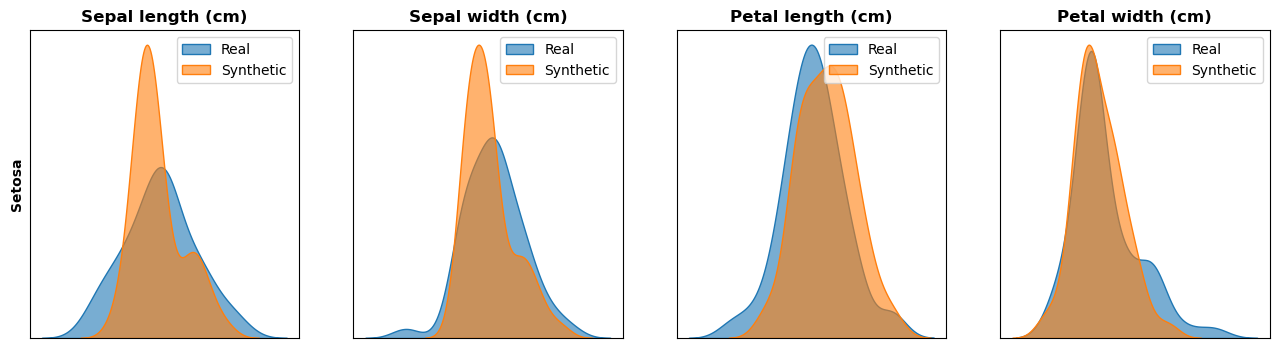

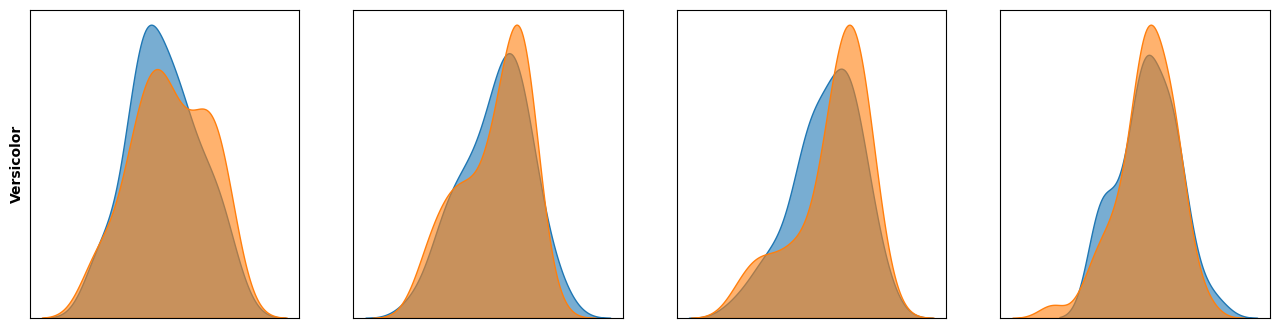

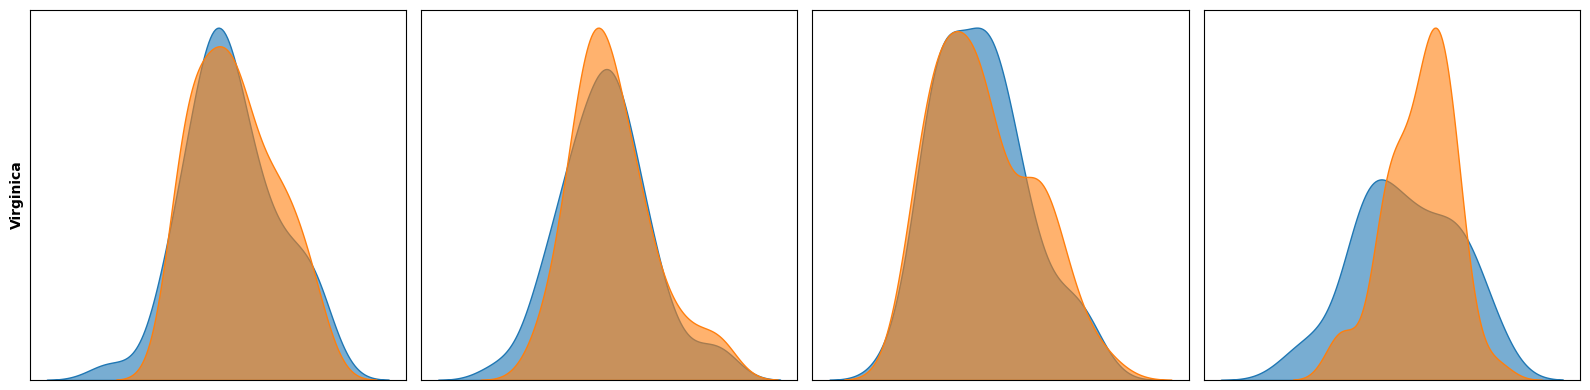

In [108]:
df_real = pd.DataFrame(X_real)
df_real['target'] = y_real

df_fake = pd.DataFrame(syntethic_data_trained)
df_fake['target'] = np.array(combined_tensor)

species = load_iris()['target_names']
title = load_iris()['feature_names']


for row in range(3):
    fig, ax = plt.subplots(1, 4, figsize = (16,4))
    
    for i in range(4):
        sns.kdeplot(data = df_real[df_real['target'] == row], x = i, ax = ax[i], fill = True, alpha = 0.6)
        sns.kdeplot(data = df_fake[df_fake['target'] == row], x = i, ax = ax[i], fill = True, alpha = 0.6)
        
        if i == 0:
            ax[i].set_ylabel(species[row].capitalize(), weight = 'bold')
        else:
            ax[i].set_ylabel('')
            
        if row == 0:
            ax[i].set_title(title[i].capitalize(), weight = 'bold')
            ax[i].legend(['Real', 'Synthetic'], loc='upper right')
        
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].set_xlabel('')
        
plt.tight_layout();

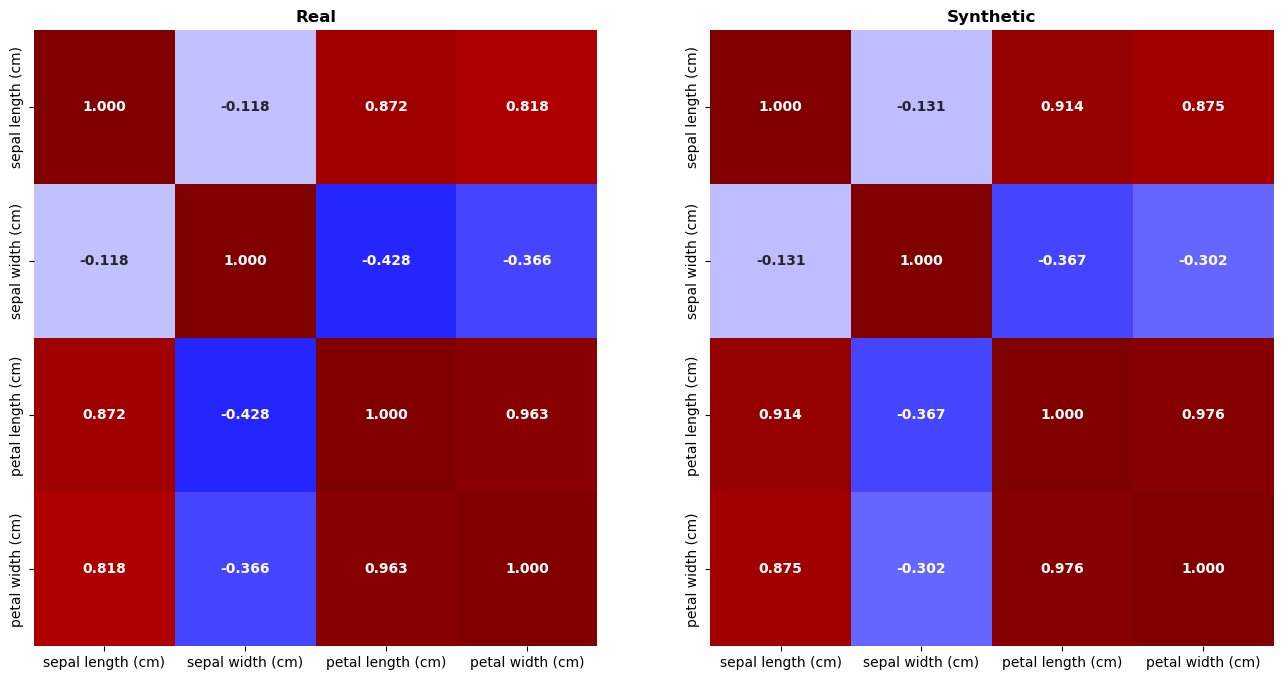

In [109]:
datasets = [df_real, df_fake]
data_reality = ['Real', 'Synthetic']

fig, ax = plt.subplots(1, 2 ,figsize = (16, 8))

for i in range(2):
    sns.heatmap(data = datasets[i].iloc[:,:4].corr(), ax = ax[i], annot = True, fmt = '.3f',cbar = False, 
                cmap = 'seismic', vmin = -1, vmax = 1, annot_kws = {'weight':'bold'}, 
                xticklabels = title, yticklabels = title)
    ax[i].set_title(data_reality[i], weight = 'bold')

In [110]:
#torch.save(gen.state_dict(), 'models/optimized_gen.pth')

In [111]:
real_corr = np.corrcoef(real_data, rowvar=False)
synthetic_corr = np.corrcoef(syntethic_data_trained, rowvar=False)
    
diff = np.abs(real_corr - synthetic_corr)
mace = np.mean(diff)
mace

0.12382373318418796

In [112]:
from scipy.stats import ks_2samp

def calculate_ks_test(real_data, synthetic_data):
    results = []
    for i in range(real_data.shape[1]):  # Per ogni feature
        ks_stat, p_value = ks_2samp(real_data[:, i], synthetic_data[:, i])
        results.append({'Feature': i, 'KS Statistic': ks_stat, 'P-Value': p_value})
    return pd.DataFrame(results)

calculate_ks_test(X_real, syntethic_data_trained)

,Feature,KS Statistic,P-Value
0,0,0.100000,0.442524
1,1,0.120000,0.230782
2,2,0.106667,0.361727
3,3,0.113333,0.291074


In [113]:
samples = 500

tensor1 = torch.zeros(samples, dtype = torch.long)
tensor2 = torch.ones(samples, dtype = torch.long)
tensor3 = torch.full((samples,), 2, dtype = torch.long)

large_tensor = torch.cat([tensor1, tensor2, tensor3])

In [114]:
std_scl.inverse_transform(gen(torch.randn(3*samples, noise_dim), large_tensor).detach().numpy())

array([[5.426912  , 3.8599997 , 1.7598135 , 0.39794967],
       [4.5334086 , 2.829457  , 1.0468566 , 0.0353383 ],
       [4.814026  , 3.1984053 , 1.4006836 , 0.20099951],
       ...,
       [5.979369  , 2.9711933 , 4.797235  , 1.9483736 ],
       [7.2193527 , 2.6950538 , 6.4977064 , 2.1351125 ],
       [5.9636497 , 2.7897701 , 4.8511605 , 1.7547421 ]], dtype=float32)

In [115]:
fake_gan_dataset = IrisDataset(std_scl.transform(std_scl.inverse_transform(gen(torch.randn(3*samples, noise_dim), large_tensor).detach().numpy())), np.array(large_tensor))
fake_gan_dataloader = DataLoader(fake_gan_dataset, batch_size = samples * 3, shuffle = True)

for i in fake_gan_dataloader:
    fake_batch = i

real_clf(fake_batch[0])
clf_criterion(real_clf(fake_batch[0]), fake_batch[1])

tensor(0.0327, grad_fn=<NllLossBackward0>)

## Conclusion